<a href="https://colab.research.google.com/github/Jrnas2010/Occupancy-Detection/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Import Library :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

In [ ]:
# 2. LOAD DATASET
# Using the occupancy detection files provided
train_data = pd.read_csv('datatraining.txt')
test_data = pd.read_csv('datatest.txt')
test_data = pd.read_csv('datatest2.txt')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3. FEATURE SELECTION
# Define environmental features and the target 'Occupancy' (0=Empty, 1=Occupied)
features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
X_train = train_data[features]
y_train = train_data['Occupancy']
X_test = test_data[features]
y_test = test_data['Occupancy']

In [ ]:
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 8143 | Testing samples: 9752


In [ ]:
# 4. DECISION TREE IMPLEMENTATION
# We limit depth to 4 to ensure the model logic is interpretable for the report
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

In [ ]:
# 5. NEAREST-NEIGHBOR (KNN) IMPLEMENTATION
# Standard k=5 approach
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

In [ ]:
# 6. EVALUATION AND COMPARISON
print("\n" + "="*30)
print("DECISION TREE RESULTS")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(classification_report(y_test, dt_preds))


DECISION TREE RESULTS
Accuracy: 0.9260
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7703
           1       0.85      0.79      0.82      2049

    accuracy                           0.93      9752
   macro avg       0.90      0.88      0.89      9752
weighted avg       0.92      0.93      0.93      9752



In [ ]:
print("\n" + "="*30)
print("KNN RESULTS")
print(f"Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print(classification_report(y_test, knn_preds))


KNN RESULTS
Accuracy: 0.9622
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7703
           1       0.86      0.98      0.92      2049

    accuracy                           0.96      9752
   macro avg       0.93      0.97      0.95      9752
weighted avg       0.97      0.96      0.96      9752



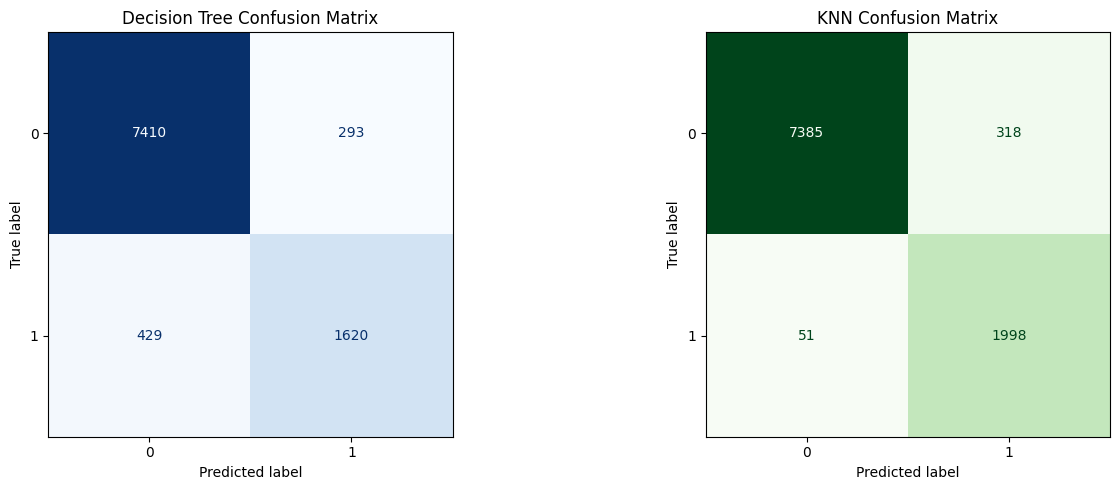

In [ ]:
# 7. VISUALIZATION FOR IEEE REPORT
# Comparison of Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree CM
ConfusionMatrixDisplay.from_predictions(y_test, dt_preds, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Decision Tree Confusion Matrix')

# KNN CM
ConfusionMatrixDisplay.from_predictions(y_test, knn_preds, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('KNN Confusion Matrix')

plt.tight_layout()
plt.show()

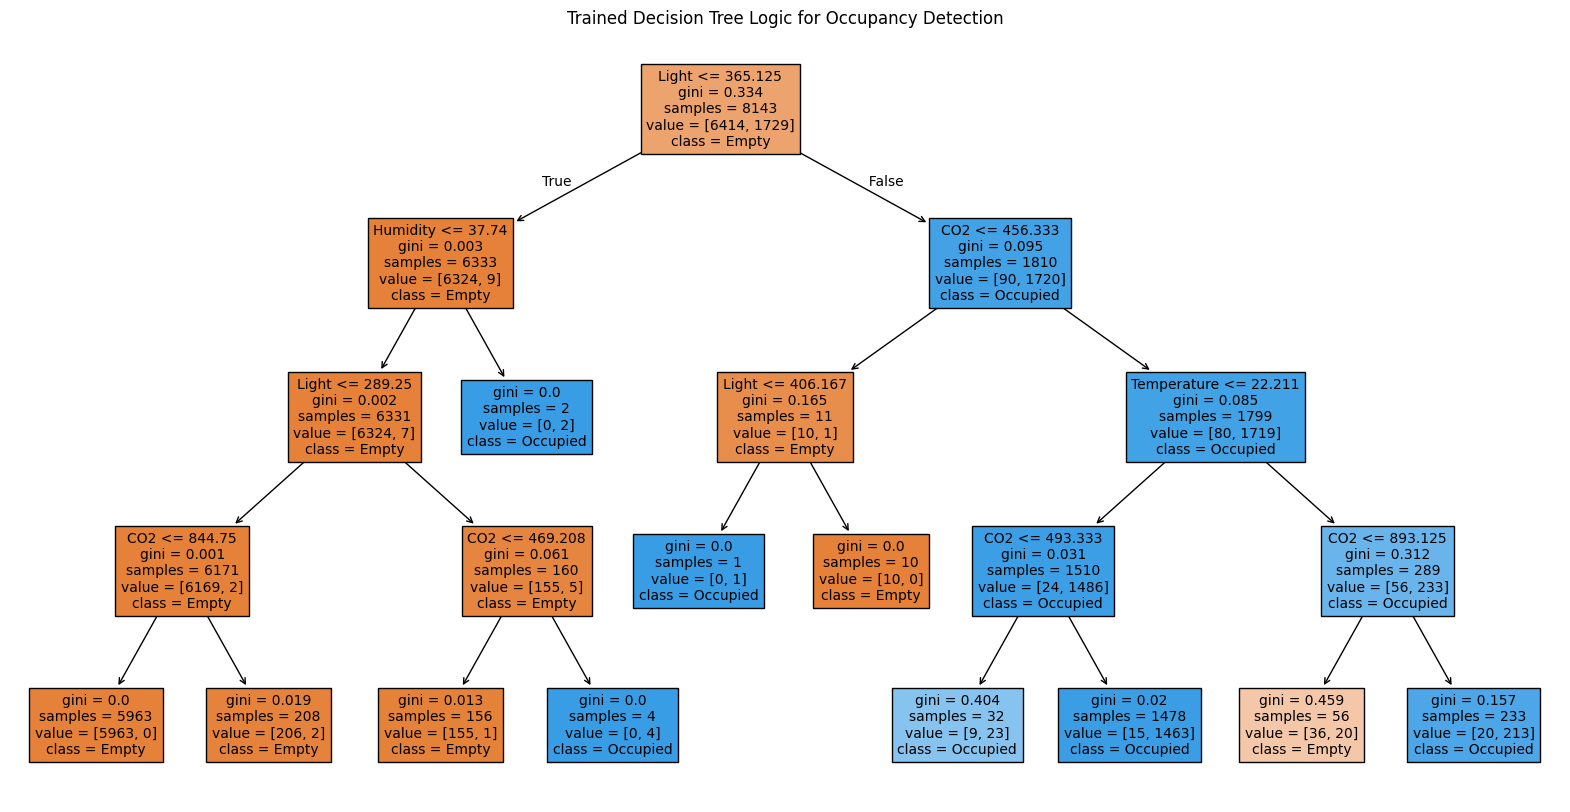

In [ ]:
# Visualize the Decision Tree Structure
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=features, class_names=['Empty', 'Occupied'], filled=True, fontsize=10)
plt.title("Trained Decision Tree Logic for Occupancy Detection")
plt.show()

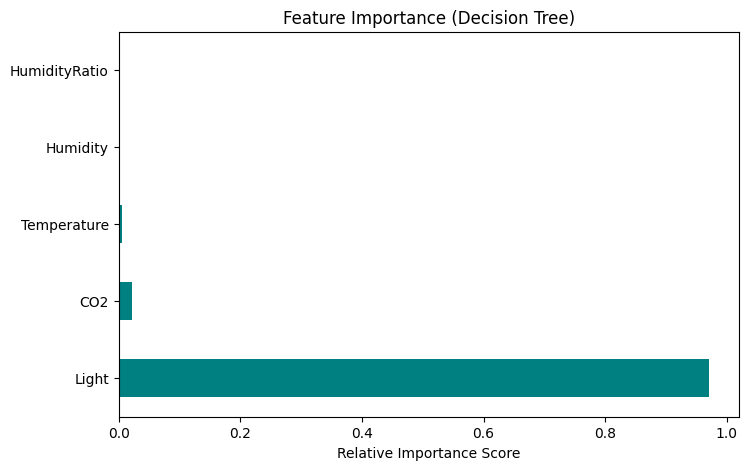

In [ ]:
# Feature Importance Plot
plt.figure(figsize=(8, 5))
feat_importances = pd.Series(dt_model.feature_importances_, index=features)
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Relative Importance Score')
plt.show()